In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

In [2]:
# 1. Generate synthetic 2D data
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

In [3]:
# 2. Train Generative and Discriminative Models
model_generative = GaussianNB()
model_generative.fit(X, y)

model_discriminative = LogisticRegression()
model_discriminative.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [4]:
# 3. Create a mesh grid for decision boundary visualization
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict on grid for both models
Z_g = model_generative.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z_d = model_discriminative.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

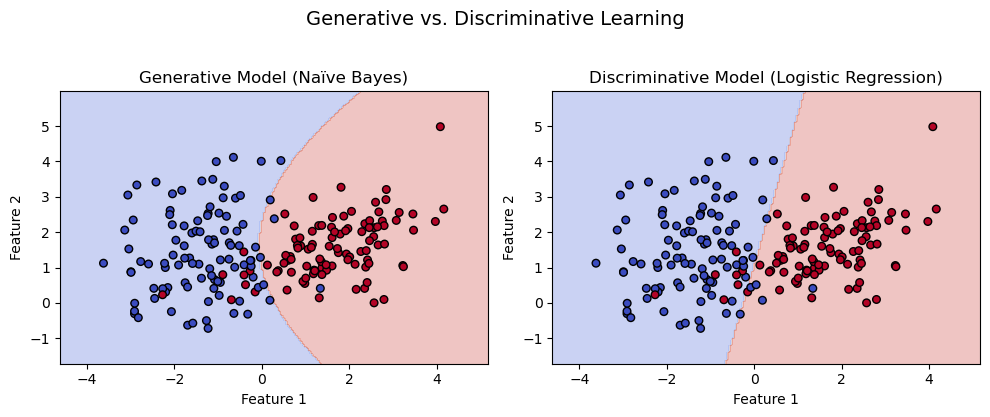

In [5]:
# 4. Plot both decision boundaries
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
titles = ['Generative Model (Naïve Bayes)', 'Discriminative Model (Logistic Regression)']

for i, (Z, model, ax, title) in enumerate(zip([Z_g, Z_d],
                                              [model_generative, model_discriminative],
                                              axes, titles)):
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.coolwarm, edgecolor='k')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())

plt.suptitle('Generative vs. Discriminative Learning', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()